# HTC

**HTC** steht für **Heat Transfer Coefficient**.

Beschreibt:

> **Wie stark eine Oberfläche Wärme mit ihrer Umgebung austauscht.**

# Randbedingug
Beschreibt, was an der Oberfläche eines Körpers thermisch passiert.

## HTC Formel:

$$
htc_{agg} = \frac{q_{summe}}{kontaktflaeche_{summe} \cdot t_{flaechengewichtet}}
$$

mit:
- `q_summe` = aggregierter Wärmestrom
- `kontaktflaeche_summe` = aggregierte Fläche
- `t_flaechengewichtet` = flächengewichtete Temperaturdifferenz

In [1]:
# ============================================================
# Funktion: HTC-Heatup-Vergleich für ein Element
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

datei = Path("../verarbeitete_daten/region_zeit_aggregation.csv")
df = pd.read_csv(datei)

schwelle_t = 1e-4
df_htc = df.copy()

df_htc["htc_agg"] = np.where(
    df_htc["t_flaechengewichtet"] >= schwelle_t,
    df_htc["q_summe"] / (df_htc["kontaktflaeche_summe"] * df_htc["t_flaechengewichtet"]),
    np.nan
)

def zeige_htc_heatup_vergleich(df_htc, element_name, heatup_cases=("Case1", "Case3", "Case5", "Case6", "Case7"), time_min=100):
    import matplotlib.pyplot as plt
    
    oberflaechen = ["top_surface", "bottom_surface", "lateral", "support"]

    df_element = df_htc[
        (df_htc["element"] == element_name) &
        (df_htc["case"].isin(heatup_cases))
    ].copy()

    df_element_spaet = df_element[df_element["time_s"] >= time_min].copy()

    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    axes = axes.flatten()

    for ax, region in zip(axes, oberflaechen):
        daten_region = df_element_spaet[df_element_spaet["region_group"] == region]

        for case_name in heatup_cases:
            daten_case = daten_region[daten_region["case"] == case_name]
            ax.plot(daten_case["time_s"], daten_case["htc_agg"], label=case_name)

        ax.set_title(region)
        ax.set_xlabel("Zeit [s]")
        ax.set_ylabel("htc_agg [W/m²K]")
        ax.grid(True)
        ax.legend()

    plt.suptitle(f"{element_name}: aggregierter HTC für die Heatup-Cases (ab {time_min} s)", y=1.02)
    plt.tight_layout()
    plt.show()

    # ==========================================
    # 1. Die Steady-State Tabelle (Das Ende der Simulation)
    # ==========================================
    # Wir schneiden das Aufheiz-Chaos der ersten Stunden ab und schauen 
    # nur auf die perfekten, flachen Linien am Ende (ab Sekunde 15.000).
    steady_state_start = 15000 
    
    df_steady_state = df_element[df_element["time_s"] >= steady_state_start].copy()
    
    # Wir berechnen den Mittelwert (mean) nur für diese allerletzte Phase.
    # min, max und median brauchen wir nicht mehr, da die Linie ja ohnehin flach ist.
    summary_cases = (
        df_steady_state
        .groupby(["region_group", "case"])["htc_agg"]
        .agg(["mean"]) 
        .reset_index()
        .rename(columns={"mean": "HTC_SteadyState"})
    )
    
    # ==========================================
    # 2. Die Daumenregel ("Generalize boundary conditions")
    # ==========================================
    # Jetzt erfüllen wir den Zeiss-Auftrag: "apply ONE boundary condition for all settings"
    # Wir nehmen die HTC-Werte aus Case 1, 3 und 5 und bilden daraus EINEN finalen Durchschnitt.
    zeiss_daumenregel = (
        summary_cases
        .groupby("region_group")["HTC_SteadyState"]
        .agg(["mean"])
        .reset_index()
        .rename(columns={"mean": "Generalisierter_HTC_Zeiss"})
    )

    # Wir geben beide Tabellen zurück, damit du sie dir ausdrucken/anzeigen lassen kannst
    return summary_cases, zeiss_daumenregel

# =========================================================
# Funktion: HTC-Cooldown-Vergleich (Abkühlphase)
# =========================================================
def zeige_htc_cooldown_vergleich(df_htc, element_name, cooldown_cases=("Case2", "Case4"), time_min=100):
    import matplotlib.pyplot as plt
    
    oberflaechen = ["top_surface", "bottom_surface", "lateral", "support"]
    
    df_element = df_htc[
        (df_htc["element"] == element_name) & 
        (df_htc["case"].isin(cooldown_cases))
    ].copy()
    
    df_element_spaet = df_element[df_element["time_s"] >= time_min].copy()
    
    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    axes = axes.flatten()
    
    for ax, region in zip(axes, oberflaechen):
        daten_region = df_element_spaet[df_element_spaet["region_group"] == region]
        
        for case_name in cooldown_cases:
            daten_case = daten_region[daten_region["case"] == case_name]
            ax.plot(daten_case["time_s"], daten_case["htc_agg"], label=case_name)
            
        ax.set_title(region)
        ax.set_xlabel("Zeit [s]")
        ax.set_ylabel("HTC_agg [W/m²K]")
        ax.grid(True)
        ax.legend()
        
    plt.suptitle(f"{element_name}: Aggregierter HTC für die Cooldown-Cases (ab {time_min} s)", y=1.02, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ==========================================
    # Tabellen-Berechnung (Steady State)
    # ==========================================
    steady_state_start = 15000 
    df_steady_state = df_element[df_element["time_s"] >= steady_state_start].copy()
    
    summary_cases = (
        df_steady_state
        .groupby(["region_group", "case"])["htc_agg"]
        .agg(["mean"]) 
        .reset_index()
        .rename(columns={"mean": "HTC_SteadyState"})
    )
    
    zeiss_daumenregel_cooldown = (
        summary_cases
        .groupby("region_group")["HTC_SteadyState"]
        .agg(["mean"])
        .reset_index()
        .rename(columns={"mean": "Generalisierter_HTC_Cooldown"})
    )
    
    return summary_cases, zeiss_daumenregel_cooldown

# =========================================================
# AUSFÜHRUNG: Hier rufen wir die Funktion auf!
# =========================================================
# Um das auszuführen, schreibe einfach ganz unten in dein Skript:
# summary_cool, daumenregel_cool = zeige_htc_cooldown_vergleich(df_htc, "Element3")
# print(daumenregel_cool)

# HTC pro Fläche pro Case (Heat Up)

--- HEATUP PHASE: Element1 ---


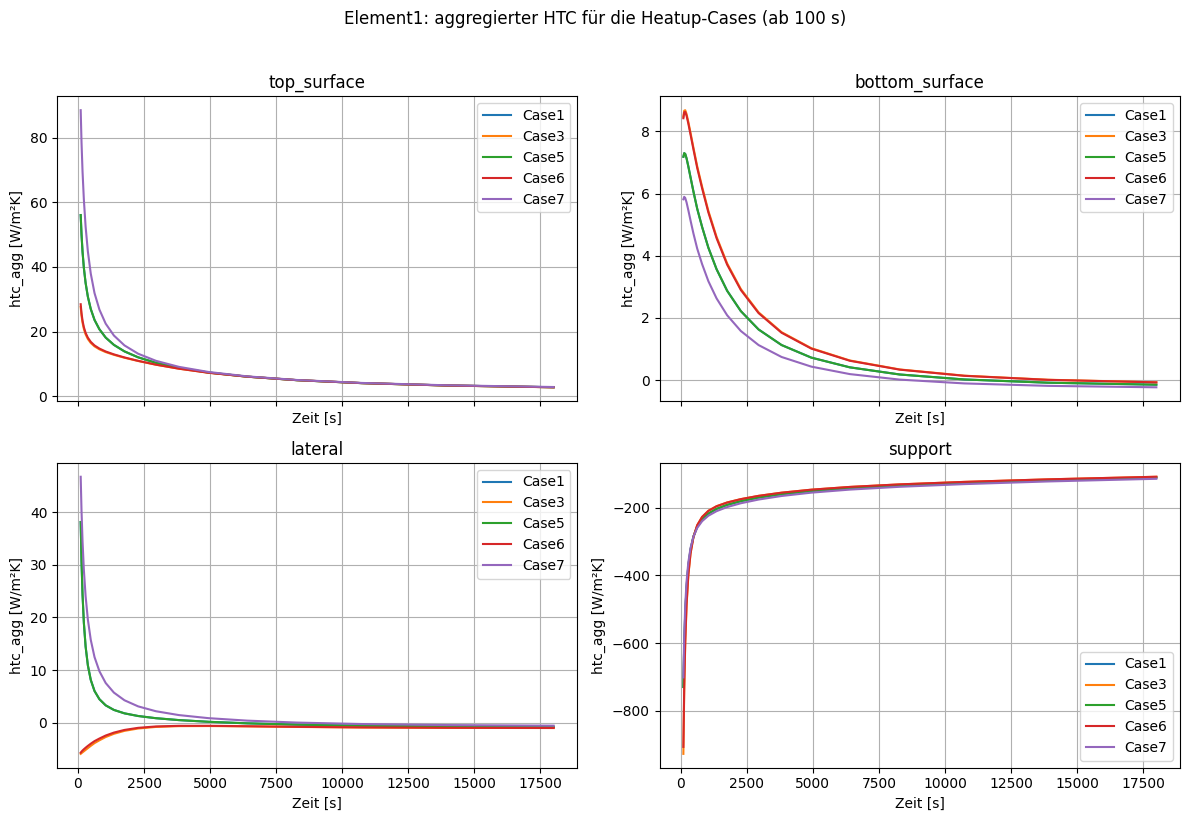

      region_group   case  HTC_SteadyState
0   bottom_surface  Case1        -0.150000
1   bottom_surface  Case3        -0.072863
2   bottom_surface  Case5        -0.150000
3   bottom_surface  Case6        -0.075654
4   bottom_surface  Case7        -0.233912
5          lateral  Case1        -0.736306
6          lateral  Case3        -0.963924
7          lateral  Case5        -0.736306
8          lateral  Case6        -0.952140
9          lateral  Case7        -0.517092
10         support  Case1      -111.228041
11         support  Case3      -108.877140
12         support  Case5      -111.228041
13         support  Case6      -108.828613
14         support  Case7      -114.833853
15     top_surface  Case1         2.810395
16     top_surface  Case3         2.796183
17     top_surface  Case5         2.810395
18     top_surface  Case6         2.791587
19     top_surface  Case7         2.878240
     region_group  Generalisierter_HTC_Zeiss
0  bottom_surface                  -0.136486
1      

In [9]:
# === ANALYSE FÜR LINSE 1 ===
element_name = "Element1"

print(f"--- HEATUP PHASE: {element_name} ---")
summary_heat, daumenregel_heat = zeige_htc_heatup_vergleich(df_htc, element_name)
print(summary_heat)
print(daumenregel_heat)



# HTC pro Fläche pro Case (Cooldown)

--- COOLDOWN PHASE: Element1 ---


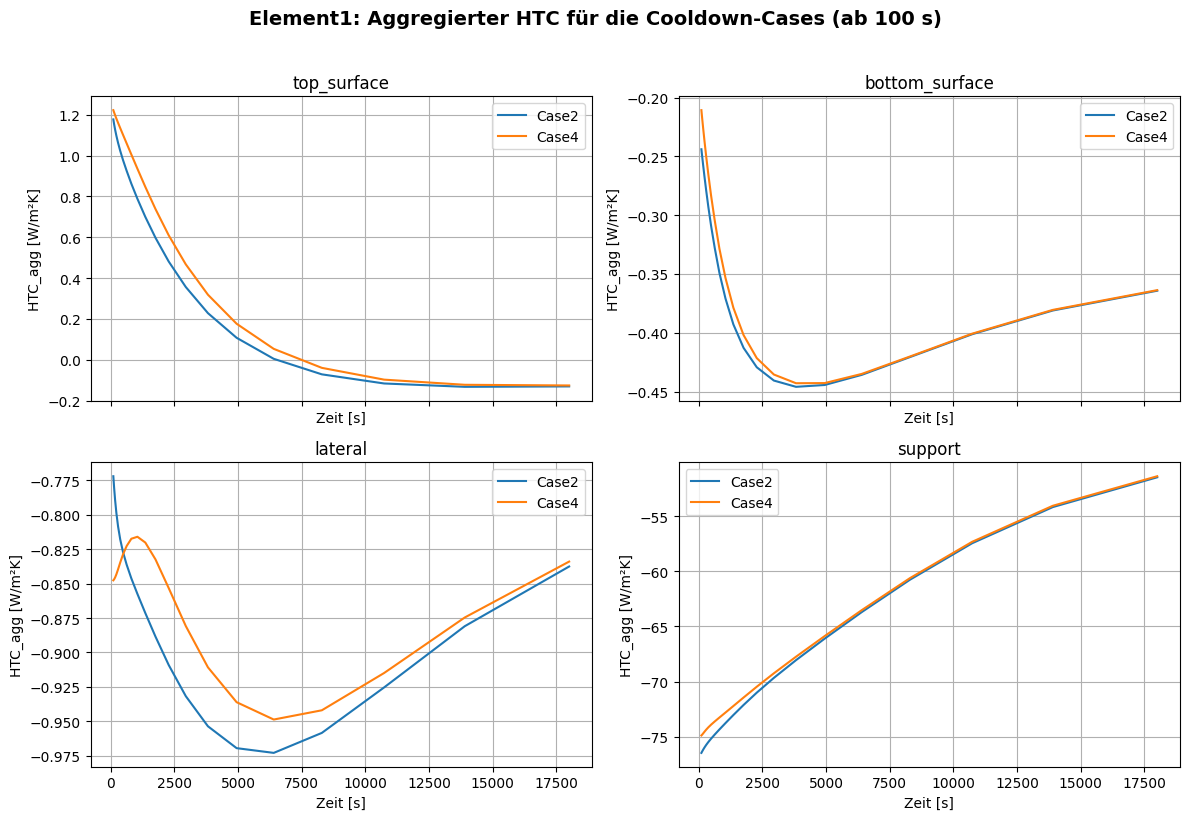

     region_group   case  HTC_SteadyState
0  bottom_surface  Case2        -0.364239
1  bottom_surface  Case4        -0.363754
2         lateral  Case2        -0.837641
3         lateral  Case4        -0.834070
4         support  Case2       -51.466224
5         support  Case4       -51.371169
6     top_surface  Case2        -0.130916
7     top_surface  Case4        -0.126302
     region_group  Generalisierter_HTC_Cooldown
0  bottom_surface                     -0.363996
1         lateral                     -0.835856
2         support                    -51.418696
3     top_surface                     -0.128609


In [17]:


print(f"--- COOLDOWN PHASE: {element_name} ---")
summary_cool, daumenregel_cool = zeige_htc_cooldown_vergleich(df_htc, element_name)
print(summary_cool)
print(daumenregel_cool)

# Curve Fitting (vor 15000s)

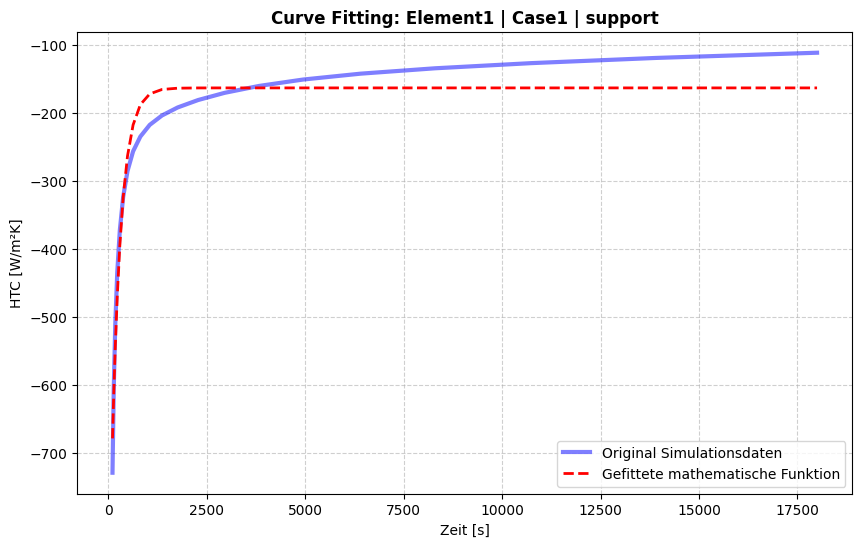

DIE FINALE FUNKTION FÜR ZEISS:
h(t) = -800.21 * e^(-0.00430 * t) -163.04
------------------------------------------------------------
Bedeutung:
- Der Parameter 'c' (-163.04) ist unser Steady-State Wert!
- Wenn die Ingenieure diese Formel in Python oder Excel tippen,
  können sie den HTC für jede beliebige Sekunde 't' berechnen.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =========================================================
# 1. Daten vorbereiten (Linse 1, Case 1, Support)
# =========================================================
element_name = "Element1"
case_name = "Case1"
region_name = "support"

# Wir filtern die Daten (ab 100s, um die Start-Spikes zu ignorieren)
df_fit = df_htc[
    (df_htc["element"] == element_name) & 
    (df_htc["case"] == case_name) & 
    (df_htc["region_group"] == region_name) &
    (df_htc["time_s"] >= 100)
].copy()

# X- und Y-Achse für das Fitting
t_data = df_fit["time_s"].values
h_data = df_fit["htc_agg"].values

# =========================================================
# 2. Die mathematische Funktion definieren
# =========================================================
def exponential_funktion(t, a, b, c):
    return a * np.exp(-b * t) + c

# =========================================================
# 3. Curve Fitting anwenden (Die Magie von SciPy)
# =========================================================
# p0 sind unsere "Start-Schätzwerte" für a, b und c, damit SciPy schneller rechnet.
# Für c nehmen wir euren gefundenen Steady-State Wert (ca. -190)
start_schaetzung = [-1000, 0.001, -190] 

# curve_fit sucht nun die optimalen Parameter
optimale_parameter, covariance = curve_fit(exponential_funktion, t_data, h_data, p0=start_schaetzung)

a_opt, b_opt, c_opt = optimale_parameter

# Wir berechnen die Y-Werte unserer neuen, perfekten Formel
h_fit = exponential_funktion(t_data, a_opt, b_opt, c_opt)

# =========================================================
# 4. Ergebnisse visualisieren & ausdrucken
# =========================================================
plt.figure(figsize=(10, 6))
plt.plot(t_data, h_data, label="Original Simulationsdaten", color="blue", linewidth=3, alpha=0.5)
plt.plot(t_data, h_fit, label="Gefittete mathematische Funktion", color="red", linestyle="--", linewidth=2)

plt.title(f"Curve Fitting: {element_name} | {case_name} | {region_name}", fontweight="bold")
plt.xlabel("Zeit [s]")
plt.ylabel("HTC [W/m²K]")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

print("="*60)
print(f"DIE FINALE FUNKTION FÜR ZEISS:")
print("="*60)
print(f"h(t) = {a_opt:.2f} * e^(-{b_opt:.5f} * t) {c_opt:+.2f}")
print("-" * 60)
print(f"Bedeutung:")
print(f"- Der Parameter 'c' ({c_opt:.2f}) ist unser Steady-State Wert!")
print(f"- Wenn die Ingenieure diese Formel in Python oder Excel tippen,")
print(f"  können sie den HTC für jede beliebige Sekunde 't' berechnen.")
print("="*60)

# Doppelte genauere Exponentialfunktion

In [13]:
# ==============================================================================
# STARTWERT-CHEAT-SHEET FÜR DOPPEL-EXPONENTIAL CURVE FITTING
# Format: [a1 (schnell), b1 (schnell), a2 (langsam), b2 (langsam), c (Steady State)]
# Regel: a1 + a2 + c = Ungefährer Startwert bei t=0
# ==============================================================================

# --- 1. AUFHEIZPHASE (Heatup: Case 1, 3, 5) ---
startwerte_heatup = {
    # Startet sehr hoch (ca. 55), fällt dann steil ab auf ca. +2.8
    "top_surface":    [40, 0.01, 12, 0.0001, 2.8],
    
    # Startet extrem tief im Minus (ca. -800), steigt auf ca. -110 (bzw. -193 bei Element 3)
    "support":        [-500, 0.01, -200, 0.0001, -110], 
    
    # Startet bei ca. +38, fällt ab auf ca. -0.8
    "lateral":        [30, 0.01, 8, 0.0001, -0.8],
    
    # Startet bei ca. +9, fällt ab auf ca. -0.1
    "bottom_surface": [7, 0.01, 2, 0.0001, -0.1]
}

# --- 2. ABKÜHLPHASE (Cooldown: Case 2, 4) ---
startwerte_cooldown = {
    # Startet bei ca. +1.2, fällt ab auf ca. -0.12
    "top_surface":    [1.0, 0.01, 0.3, 0.0001, -0.12],
    
    # Startet bei ca. -75, steigt langsam auf ca. -51
    "support":        [-20, 0.01, -4, 0.0001, -51.0],
    
    # Ziemlich flach, startet bei -0.75, endet bei -0.83
    "lateral":        [0.05, 0.01, 0.03, 0.0001, -0.83],
    
    # Startet bei ca. -0.2, fällt auf ca. -0.36
    "bottom_surface": [0.1, 0.01, 0.06, 0.0001, -0.36]
}

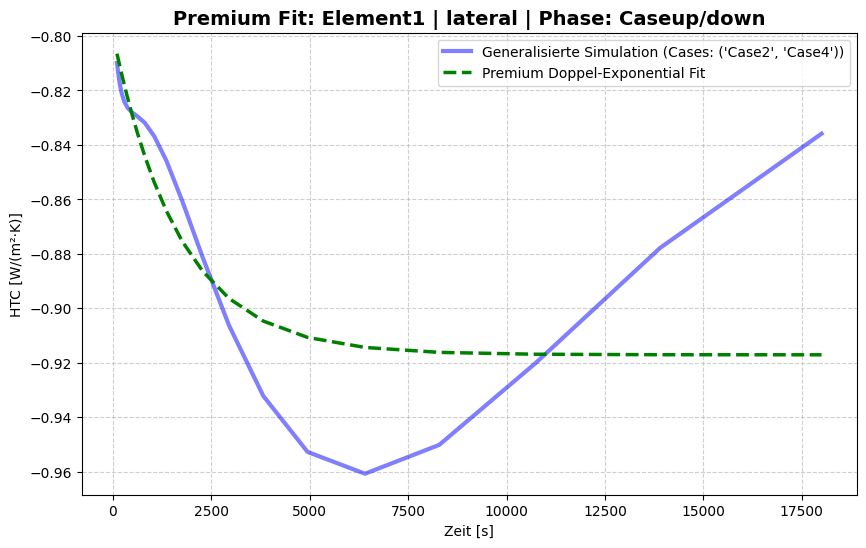

DIE FINALE GENERALISIERTE FUNKTION FÜR ZEISS (Element1 - lateral):
h(t) = 0.07 * e^(-0.00059 * t) +0.04 * e^(-0.00059 * t) -0.92
--------------------------------------------------------------------------------
Bedeutung:
- Der Parameter 'c' (-0.92) ist der finale Steady-State (TCC)!
- Diese eine Formel ersetzt alle 2 Laser-Settings für diese Fläche.


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =========================================================
# 1. Die Premium-Formel definieren
# =========================================================
def doppel_exponential(t, a1, b1, a2, b2, c):
    # a1, b1: Für die schnelle Aufheizphase (Oberfläche)
    # a2, b2: Für das langsame Kriechen (Glaskern)
    # c: Unser geliebter Steady-State!
    return a1 * np.exp(-b1 * t) + a2 * np.exp(-b2 * t) + c

# =========================================================
# 2. Die Hauptfunktion für euer Notebook
# =========================================================
def zeige_premium_curve_fit(df_htc, element_name, region_name, cases, start_schaetzung):
    
    # A) Daten filtern (nur ab 100s, um Start-Spikes auszublenden)
    df_fit = df_htc[
        (df_htc["element"] == element_name) & 
        (df_htc["case"].isin(cases)) & 
        (df_htc["region_group"] == region_name) &
        (df_htc["time_s"] >= 100)
    ].copy()
    
    # B) DER GENERALISIERUNGS-TRICK: 
    # Wir gruppieren nach der Zeit und bilden den Durchschnitt.
    # Das verschmilzt Case 1, 3 und 5 zu einer perfekten Linie!
    df_generalized = df_fit.groupby("time_s")["htc_agg"].mean().reset_index()
    
    t_data = df_generalized["time_s"].values
    h_data = df_generalized["htc_agg"].values
    
    # C) Curve Fitting anwenden
    # maxfev=10000 gibt dem PC mehr Zeit für diese komplexe Formel
    opt_params, _ = curve_fit(doppel_exponential, t_data, h_data, p0=start_schaetzung, maxfev=10000)
    a1_opt, b1_opt, a2_opt, b2_opt, c_opt = opt_params
    
    # D) Die Y-Werte für unsere fertige Formel berechnen
    h_fit = doppel_exponential(t_data, a1_opt, b1_opt, a2_opt, b2_opt, c_opt)
    
    # E) Das Diagramm zeichnen
    plt.figure(figsize=(10, 6))
    plt.plot(t_data, h_data, label=f"Generalisierte Simulation (Cases: {cases})", color="blue", linewidth=3, alpha=0.5)
    plt.plot(t_data, h_fit, label="Premium Doppel-Exponential Fit", color="green", linestyle="--", linewidth=2.5)
    
    plt.title(f"Premium Fit: {element_name} | {region_name} | Phase: {cases[0][:4]}up/down", fontweight="bold", fontsize=14)
    plt.xlabel("Zeit [s]")
    plt.ylabel("HTC [W/(m²·K)]")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()
    
    # F) Formel für Zeiss ausdrucken
    print("="*80)
    print(f"DIE FINALE GENERALISIERTE FUNKTION FÜR ZEISS ({element_name} - {region_name}):")
    print("="*80)
    print(f"h(t) = {a1_opt:.2f} * e^(-{b1_opt:.5f} * t) {a2_opt:+.2f} * e^(-{b2_opt:.5f} * t) {c_opt:+.2f}")
    print("-" * 80)
    print(f"Bedeutung:")
    print(f"- Der Parameter 'c' ({c_opt:.2f}) ist der finale Steady-State (TCC)!")
    print(f"- Diese eine Formel ersetzt alle {len(cases)} Laser-Settings für diese Fläche.")
    print("="*80)



zeige_premium_curve_fit(
    df_htc=df_htc, 
    element_name="Element1", 
    region_name="lateral", 
    cases=("Case2", "Case4"), 
    start_schaetzung=startwerte_cooldown["lateral"]
)
# oder startwerte_cooldown
